# Geophysics Workshop for Baltic Precambrian Geologists

Arbavere, Estonia. 28.05.2026

**The aim:** estimate the amount of iron ore in the Inčukalns deposit.

**The outline:**
1. General information on the Inčukalns magnetic anomaly in Central Latvia
2. Magnetic data processing
3. Modelling the ore body

Within this workshop we will perform typical routines of magnetic data processing and simple forward modelling using **Python** and **SimPEG** geophysical modelling package. The programming languages are often involved in geophysical models. **Python** specifically is a very commonly used tool.

Within this workshop we will focus on magnetic data - the geophysical modelling with gravity data is relatively similar, but, of course, uses the density differences of the rocks, instead of magnetic susceptibilities. More advanced models typically consider both data sources at the same time.

Within this tutorial we will focus on 2D modelling (geological cross sections), while generally most of the surveys are performed in 3D. The math is similar - but we add another dimension during the approximation of the data.

*Disclaimer: parts of the script are based on Python package "SimPEG" tutorials.*

# Jupyter notebook

To follow the workshop, we must understand how a Jupyer Notebook works.
Below we will find `cells` that containt Python code. It can be interactively executed to give commands to the computer, which then give an output.

The important part is **the cell content can be changed and run again**. This way, we will later adjust the model parameters and run the model again, getting a **different result**

In [2]:
# This is a cell. It containts Python code that can be executed
1 / 2

0.5

## The Inčukalns magnetic anomaly

We start first by investingating the Inčukalns magnetic anomaly.

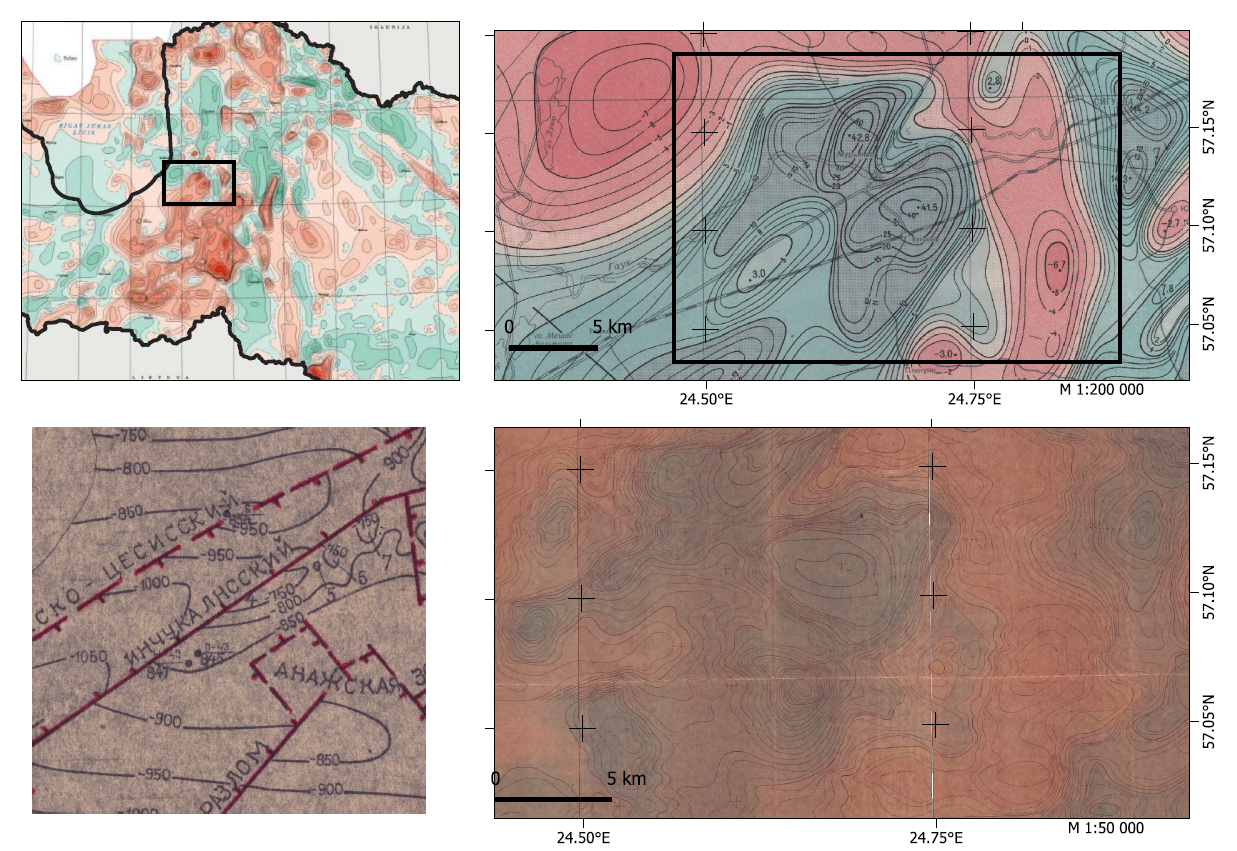

**Top-left:** regional aeromagnetic map of Central Latvia, with Inčukalns area in marked. Red color shows higher magnetic intensity.
**Top-right:** aeromagnetic map of the Inčukalns area, original scale 1:200 000. Blue color shows higher magnetic intensity.
**Bottom-left:** Precambrian basement surface area around Inčukalns area with known and possible faults denoted.
**Bottom-right:** aeromagnetic map of the Inčukalns area, original scale 1:50 000. The anomalies of interest are in the center of image. Blue color shows higher magnetic intensity.

## Workspace preparation and data import

Within this notebook we will call multiple python functions and code. We will try to explain to our best ability what the code does; however to understand the topic deeper and investigate further we recommend reading up on Python programming language and basic routines.

We here run two cells - one for setting up Python environment and one for reading in and sorting the magnetometer data.

In [3]:
# This snippet reads in the the necessary libraries - python language extensions
#   that will be employed in geophysical processing.
import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pyproj
from sklearn.decomposition import PCA
from scipy.interpolate import LinearNDInterpolator

# SimPEG functionality
from simpeg.potential_fields import magnetics
from simpeg.utils import plot2Ddata, model_builder
from simpeg import maps

# discretize functionality
from discretize import TensorMesh
from discretize.utils import mkvc, active_from_xyz

In [4]:
# Read in the base station data
base = pd.read_csv("./data/base.txt",
                        delimiter=" ",
                        header=None,
                        usecols=[4, 6],
                        names=["time", "nT"]
                        )[10:-10] # Removing first and last values which are noisy due to mag setup operations
# Subtract first value from others to get the difference. Divide by 10 because Geometrics G856 doesnt write the comma.
base["nT"] = (base["nT"] - base["nT"].values[0]) / 10 
# Reformat the time values to `datetime` for formatting
base["time"] = pd.to_datetime(base["time"], format="%H%M%S")

# Read in the rover1 data
rover1 = pd.read_csv("./data/rover1.txt",
                        delimiter=" ",
                        skiprows=12,
                        # header=None,
                        usecols=[1, 3, 7, 13],
                        names=["latitude", "longitude", "nT", "time"]
                        ) # Removing first and last values which are noisy due to mag setup operations
# Remove rows that denote next waypoint line, which is characteristic for GEM magnetometers
rover1 = rover1[~rover1["latitude"].astype(str).str.startswith("line")]
# Remove some faulty rows
rover1 = rover1[~rover1["time"].astype(str).str.contains(r"\*")]
# Remove additional rows with faulty coordinates
rover1 = rover1[rover1["latitude"] != 0]
# Convert time values to `datetime` for formatting
rover1["time"] = pd.to_datetime(rover1["time"], format="%H%M%S.%f")


# Read in the rover2 data
rover2 = pd.read_csv("./data/rover2.txt",
                        delimiter=" ",
                        skiprows=12,
                        # header=None,
                        usecols=[1, 3, 7, 13],
                        names=["latitude", "longitude", "nT", "time"]
                        ) # Removing first and last values which are noisy due to mag setup operations
# Remove rows that denote next waypoint line, which is characteristic for GEM magnetometers
rover2 = rover2[~rover2["latitude"].astype(str).str.startswith("line")]
# Remove some faulty rows
rover2 = rover2[~rover2["time"].astype(str).str.contains(r"\*")]
# Remove additional rows with faulty coordinates
rover2 = rover2[rover2["latitude"] != 0]
# Convert time values to `datetime` for formatting
rover2["time"] = pd.to_datetime(rover2["time"], format="%H%M%S.%f")

# Reproject the data to a local coordinate system
# We will work in Latvian projected coordinate system - LKS92
# The values will be added as x and y columns to the dataset
transformer = pyproj.Transformer.from_crs(
    crs_from="EPSG:4326",
    crs_to="EPSG:3059",
    always_xy=True
)

rover1["x"], rover1["y"] = (
    np.array(v).round(0) 
    for v in transformer.transform(rover1["longitude"].values, rover1["latitude"].values)
)

rover2["x"], rover2["y"] = (
    np.array(v).round(0) 
    for v in transformer.transform(rover2["longitude"].values, rover2["latitude"].values)
)

Lets investigate how the `base` data looks.

In [5]:
base

,time,nT
10,1900-01-01 07:07:03,0.0
11,1900-01-01 07:07:33,-1.0
12,1900-01-01 07:08:03,-0.6
13,1900-01-01 07:08:33,0.2
14,1900-01-01 07:09:03,-0.4
...,...,...
694,1900-01-01 12:49:03,2.6
695,1900-01-01 12:49:33,1.4
696,1900-01-01 12:50:03,1.0
697,1900-01-01 12:50:33,0.2


Preview the added `rover1` dataset.

In [6]:
rover1

,latitude,longitude,nT,time,x,y
0,57.020756,24.622227,52080.65,1900-01-01 07:53:40,537778.0,319869.0
1,57.020756,24.622226,52083.46,1900-01-01 07:53:42,537778.0,319869.0
2,57.020756,24.622226,52080.73,1900-01-01 07:53:44,537778.0,319868.0
3,57.020758,24.622228,52082.08,1900-01-01 07:53:46,537778.0,319869.0
4,57.020759,24.622241,52079.67,1900-01-01 07:53:48,537778.0,319869.0
...,...,...,...,...,...,...
3178,57.047382,24.646595,53149.76,1900-01-01 10:51:08,539229.0,322846.0
3179,57.047378,24.646594,53150.15,1900-01-01 10:51:10,539229.0,322846.0
3180,57.047376,24.646613,53149.75,1900-01-01 10:51:12,539230.0,322845.0
3181,57.047382,24.646605,53150.00,1900-01-01 10:51:14,539230.0,322846.0


### **Plot base and rover readings**

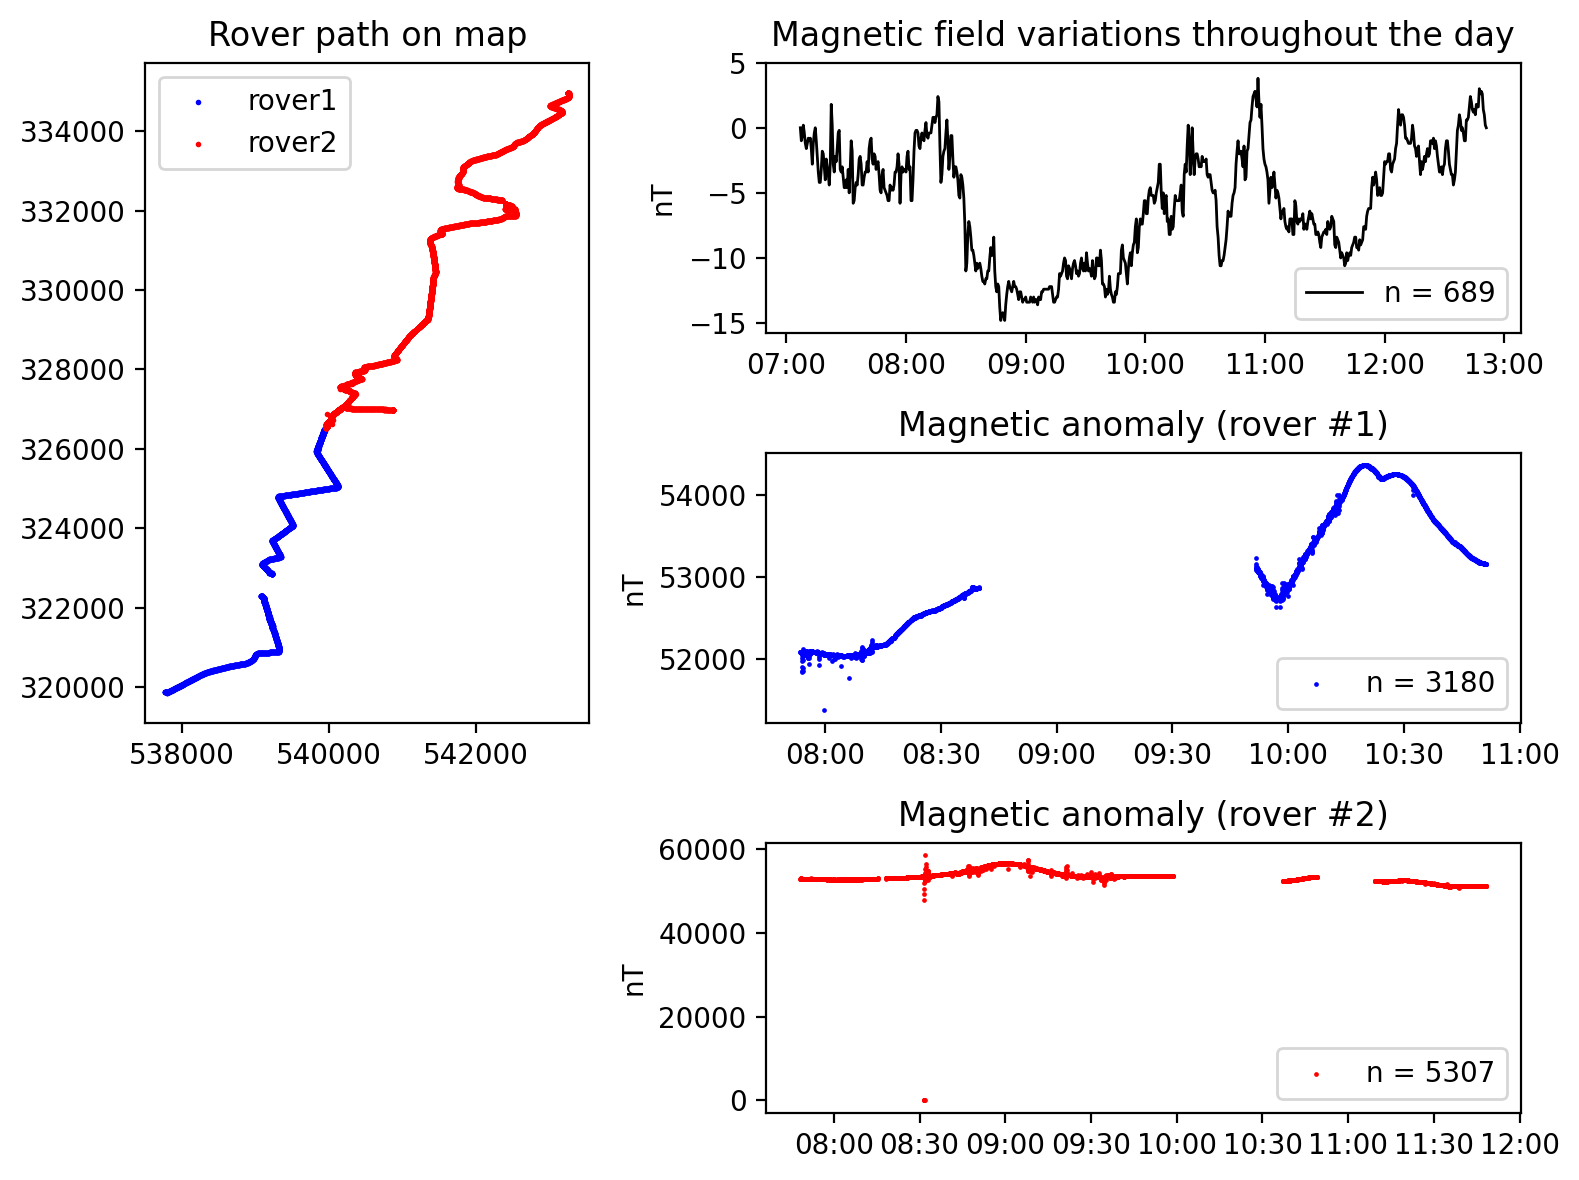

In [7]:
fig = plt.figure(figsize=(8, 6), dpi = 200)

ax1 = plt.subplot2grid((3, 5), (0, 0), rowspan=2, colspan=2)
ax2 = plt.subplot2grid((3, 5), (0, 2), colspan=3)
ax3 = plt.subplot2grid((3, 5), (1, 2), colspan=3)
ax4 = plt.subplot2grid((3, 5), (2, 2), colspan=3)

ax1.scatter(rover1["x"], rover1["y"], s=1, label="rover1", c="b")
ax1.scatter(rover2["x"], rover2["y"], s=1, label="rover2", c="r")
ax1.set_title(f"Rover path on map")
ax1.legend()

ax2.plot(base.time, base.nT, lw=1, label=f"n = {len(base["nT"])}", c="k")
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax2.set_title("Magnetic field variations throughout the day")
ax2.set_ylabel("nT")
ax2.set_yticks([-15, -10, -5, 0, 5])
ax2.legend(loc="lower right")

ax3.scatter(rover1.time, rover1.nT, s=0.5, label=f"n = {len(rover1["nT"])}", c="b")
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax3.set_ylabel("nT")
ax3.set_title("Magnetic anomaly (rover #1)")
ax3.legend(loc="lower right")

ax4.scatter(rover2.time, rover2.nT, s=0.5, label=f"n = {len(rover2["nT"])}", c="r")
ax4.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax4.set_ylabel("nT")
ax4.set_title("Magnetic anomaly (rover #2)")
ax4.legend(loc="lower right")

plt.tight_layout()
plt.show()

### **Merge the two rover datasets into one**

In [8]:
# This is now the python object containing all of our data
rover = pd.concat([rover1, rover2], ignore_index=True)

### **Straigthen out the rover path (project onto a straight line)**

For a simple the 2D model we need to project our data in a straight line.
For this we will use Principal Component Analysis (PCA), as we need to project positions perpendicular to main direction.

In [9]:
rover = rover.dropna(subset=["x", "y", "nT"]).copy()
rover_coords = rover[["x", "y"]].values
pca = PCA(n_components=1)

# Fit a line
pca.fit(rover_coords)

# Project points on line
rover["distance"] = pca.transform(rover_coords)

# Get line direction and center
center = pca.mean_
direction = pca.components_[0]

# Generate line points
t = np.linspace(rover["distance"].min(), rover["distance"].max(), len(rover))
line_points = center + np.outer(t, direction)

# Project each point onto the fitted line (get 2D coordinates on the line)
projections = pca.transform(rover_coords)  # 1D distance along line
line_coords = pca.inverse_transform(projections)  # back to 2D x, y on the line

rover['x_line'] = line_coords[:, 0]
rover['y_line'] = line_coords[:, 1]

# Sort the measurements by distance
rover = rover.sort_values('distance').reset_index(drop=True)

# Because the first data points begin at the middle of the path, we need to restart the distance counter
rover["distance"] += np.abs(rover["distance"][0]).copy()



View the added `distance`, `x_line` and `y_line` column.

In [10]:
rover

,latitude,longitude,nT,time,x,y,distance,x_line,y_line
0,57.020655,24.622575,51847.88,1900-01-01 07:54:12,537799.0,319857.0,0.000000,538196.669324,319733.295567
1,57.020662,24.622532,51842.78,1900-01-01 07:54:10,537796.0,319858.0,0.063765,538196.688265,319733.356455
2,57.020671,24.622497,51899.60,1900-01-01 07:54:08,537794.0,319859.0,0.424564,538196.795434,319733.700970
3,57.020661,24.622617,51847.65,1900-01-01 07:54:14,537801.0,319858.0,1.548935,538197.129410,319734.774594
4,57.020683,24.622467,51973.59,1900-01-01 07:54:06,537792.0,319861.0,1.740230,538197.186232,319734.957256
...,...,...,...,...,...,...,...,...,...
8478,57.155977,24.715043,51093.60,1900-01-01 11:44:32,543255.0,334976.0,16057.250142,542966.217037,335065.832759
8479,57.155977,24.715044,51093.59,1900-01-01 11:44:30,543255.0,334976.0,16057.250142,542966.217037,335065.832759
8480,57.155977,24.715044,51093.56,1900-01-01 11:44:28,543255.0,334976.0,16057.250142,542966.217037,335065.832759
8481,57.155981,24.715040,51095.58,1900-01-01 11:44:02,543255.0,334976.0,16057.250142,542966.217037,335065.832759


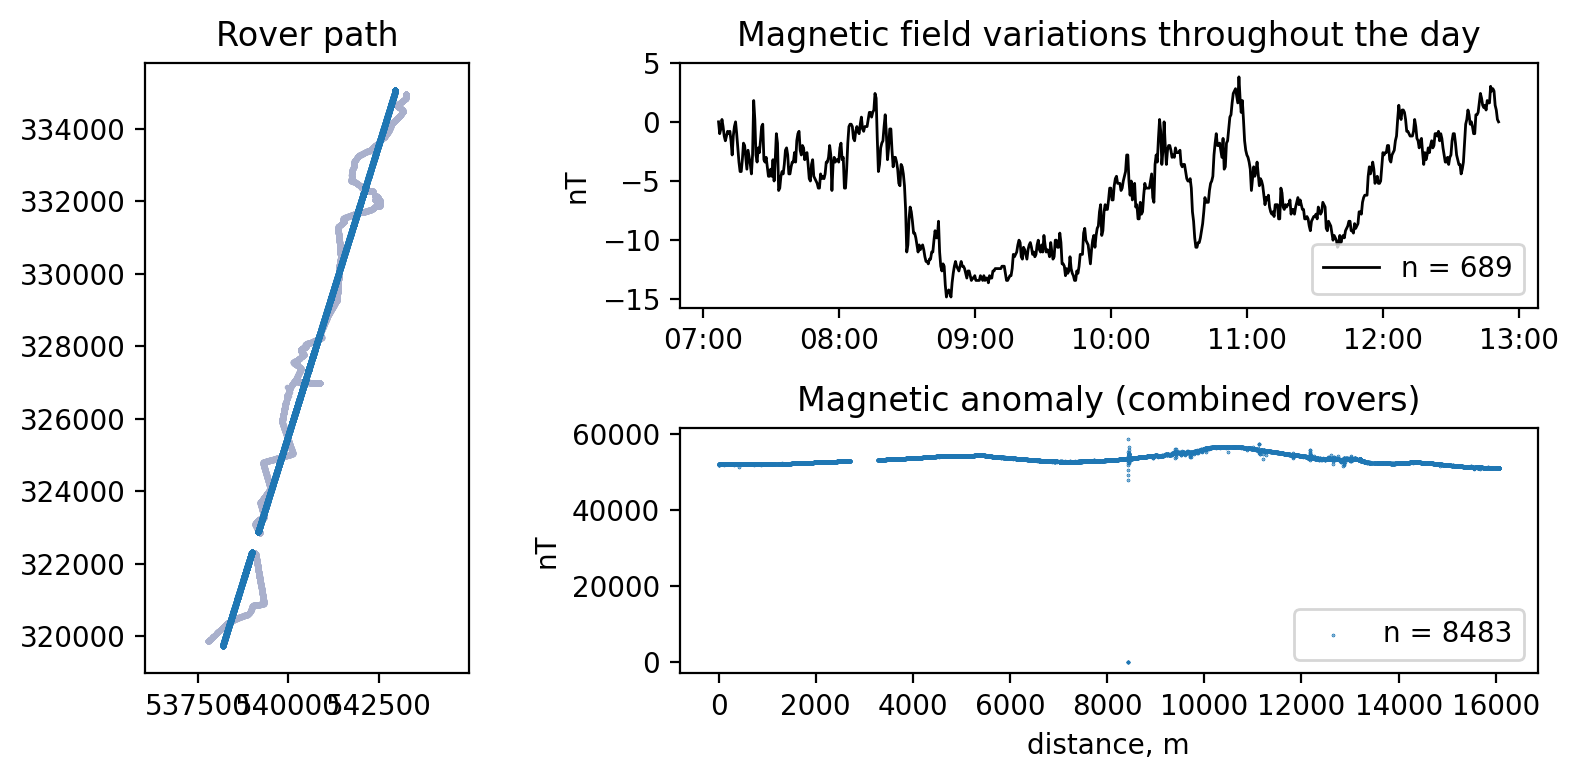

In [11]:
fig = plt.figure(figsize=(8, 4), dpi = 200)

ax1 = plt.subplot2grid((2, 3), (0, 0), rowspan=2)
ax2 = plt.subplot2grid((2, 3), (0, 1), colspan=2)
ax3 = plt.subplot2grid((2, 3), (1, 1), colspan=2)

ax1.scatter(rover["x"], rover["y"], s=1, label="original path", c="#A9B0CC")
ax1.scatter(rover["x_line"], rover["y_line"], s=1, label="line path")
ax1.set_title("Rover path")
ax1.axis("equal")

ax2.plot(base.time, base.nT, lw=1, label=f"n = {len(base["nT"])}", c="k")
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax2.set_title("Magnetic field variations throughout the day")
ax2.set_ylabel("nT")
ax2.set_yticks([-15, -10, -5, 0, 5])
ax2.legend(loc="lower right")

ax3.scatter(rover.distance, rover.nT, s=0.1, label=f"n = {len(rover["nT"])}")
ax3.set_ylabel("nT")
ax3.set_xlabel("distance, m")
ax3.set_title("Magnetic anomaly (combined rovers)")
ax3.legend(loc="lower right")

plt.tight_layout()
plt.show()

# Filtering

### **1. Diurnal correction**

Magnetic field of the Earth is constantly changing. It often changes unpredictably even within just a few hours. For this reason, we need to employ diurnal correction - measurements in a seperate location, which can be used to correct for these unpredicable changes. For this reason, we also work with a dataset `base`.

Diurnal correction is important when surveying weak anomalies. Inčukalns anomaly is very intense, so the diurnal correction largely doesn't matter, but we will do it for the sake of a good processing workflow.

In [12]:
# Sort by time
base = base.sort_values('time')
rover = rover.sort_values('time')

# Interpolate base to rover timestamps using merge_asof + interpolation
# First, reindex base to include rover timestamps
combined_time = pd.concat([base['time'], rover['time']]).drop_duplicates().sort_values()

# Interpolate base magnetic readings to all timestamps
base_interp = base.set_index('time')['nT'].reindex(combined_time)
base_interp = base_interp.interpolate(method='time')

# Extract only rover timestamps
base_at_rover = base_interp.reindex(rover['time'])

# Subtract base variation from rover (diurnal correction)
base_reference = base['nT'].mean()  # or use first value as reference
rover['nT_corr'] = rover['nT'] - base_at_rover.values + base_reference

# Sort the measurements by distance
rover = rover.sort_values('distance').reset_index(drop=True)

View the added `nT_corr` column.

In [13]:
rover

,latitude,longitude,nT,time,x,y,distance,x_line,y_line,nT_corr
0,57.020655,24.622575,51847.88,1900-01-01 07:54:12,537799.0,319857.0,0.000000,538196.669324,319733.295567,51846.318171
1,57.020662,24.622532,51842.78,1900-01-01 07:54:10,537796.0,319858.0,0.063765,538196.688265,319733.356455,51841.284838
2,57.020671,24.622497,51899.60,1900-01-01 07:54:08,537794.0,319859.0,0.424564,538196.795434,319733.700970,51898.171505
3,57.020661,24.622617,51847.65,1900-01-01 07:54:14,537801.0,319858.0,1.548935,538197.129410,319734.774594,51846.021505
4,57.020683,24.622467,51973.59,1900-01-01 07:54:06,537792.0,319861.0,1.740230,538197.186232,319734.957256,51972.228171
...,...,...,...,...,...,...,...,...,...,...
8478,57.155977,24.715043,51093.60,1900-01-01 11:44:32,543255.0,334976.0,16057.250142,542966.217037,335065.832759,51096.744838
8479,57.155977,24.715044,51093.59,1900-01-01 11:44:30,543255.0,334976.0,16057.250142,542966.217037,335065.832759,51096.748171
8480,57.155977,24.715044,51093.56,1900-01-01 11:44:28,543255.0,334976.0,16057.250142,542966.217037,335065.832759,51096.731505
8481,57.155982,24.715040,51097.63,1900-01-01 11:44:00,543255.0,334976.0,16057.250142,542966.217037,335065.832759,51100.988171


### **2. IGRF removal**

The International Geomagnetic Reference Field (IGRF) is the modelled Earth's main field (magnetic field generated in the outer core). We have to remove it to acquire the anomalous magnetic intensity. Although, the IGRF changes based on coordinates, we can apply a single value to all measurements, because, once again, Inčukalns anomaly is very intense.
Based on IGRF version 14, the mean field intensity in Inčukalns area is approximately `51980` nT.

In [14]:
rover["nT_corr"] = rover["nT_corr"] - 51980

View the updated `nT_corr` column.

In [15]:
rover

,latitude,longitude,nT,time,x,y,distance,x_line,y_line,nT_corr
0,57.020655,24.622575,51847.88,1900-01-01 07:54:12,537799.0,319857.0,0.000000,538196.669324,319733.295567,-133.681829
1,57.020662,24.622532,51842.78,1900-01-01 07:54:10,537796.0,319858.0,0.063765,538196.688265,319733.356455,-138.715162
2,57.020671,24.622497,51899.60,1900-01-01 07:54:08,537794.0,319859.0,0.424564,538196.795434,319733.700970,-81.828495
3,57.020661,24.622617,51847.65,1900-01-01 07:54:14,537801.0,319858.0,1.548935,538197.129410,319734.774594,-133.978495
4,57.020683,24.622467,51973.59,1900-01-01 07:54:06,537792.0,319861.0,1.740230,538197.186232,319734.957256,-7.771829
...,...,...,...,...,...,...,...,...,...,...
8478,57.155977,24.715043,51093.60,1900-01-01 11:44:32,543255.0,334976.0,16057.250142,542966.217037,335065.832759,-883.255162
8479,57.155977,24.715044,51093.59,1900-01-01 11:44:30,543255.0,334976.0,16057.250142,542966.217037,335065.832759,-883.251829
8480,57.155977,24.715044,51093.56,1900-01-01 11:44:28,543255.0,334976.0,16057.250142,542966.217037,335065.832759,-883.268495
8481,57.155982,24.715040,51097.63,1900-01-01 11:44:00,543255.0,334976.0,16057.250142,542966.217037,335065.832759,-879.011829


### **3. Median filtering**

Magnetic field measurements are often affected by small local factors - such as road signs or powerlines near the measurement locations.
As they do not represent the geological bodies, we have to remove them. One way to quickly remove quick local changes is by employing a running median filter. 

In [16]:
rover["nT_mf"] = rover["nT_corr"].rolling(window=100, center=True).median().copy()

# Remove data with NaN values due to median filtering
rover = rover[~np.isnan(rover["nT_mf"])]

View the added `nT_mf` column.

In [17]:
rover

,latitude,longitude,nT,time,x,y,distance,x_line,y_line,nT_corr,nT_mf
50,57.021209,24.623766,52056.21,1900-01-01 07:55:20,537871.0,319920.0,81.543058,538220.890377,319811.158337,73.721505,99.708171
51,57.021227,24.623804,52035.08,1900-01-01 07:55:22,537873.0,319922.0,84.046860,538221.634091,319813.549134,52.564838,99.799838
52,57.021243,24.623844,52031.32,1900-01-01 07:55:24,537875.0,319924.0,86.550661,538222.377805,319815.939932,48.778171,99.991505
53,57.021259,24.623875,52034.51,1900-01-01 07:55:26,537877.0,319925.0,88.099596,538222.837891,319817.418958,51.941505,100.283171
54,57.021277,24.623907,52042.79,1900-01-01 07:55:28,537879.0,319927.0,90.603398,538223.581605,319819.809756,60.194838,100.753171
...,...,...,...,...,...,...,...,...,...,...,...
8429,57.155969,24.715035,51085.58,1900-01-01 11:45:36,543255.0,334975.0,16056.295275,542965.933409,335064.920988,-891.601829,-885.425162
8430,57.155974,24.715038,51099.28,1900-01-01 11:44:38,543255.0,334975.0,16056.295275,542965.933409,335064.920988,-877.648495,-885.425162
8431,57.155970,24.715038,51090.39,1900-01-01 11:45:52,543255.0,334975.0,16056.295275,542965.933409,335064.920988,-886.365162,-885.425162
8432,57.155969,24.715039,51090.72,1900-01-01 11:46:02,543255.0,334975.0,16056.295275,542965.933409,335064.920988,-885.768495,-885.425162


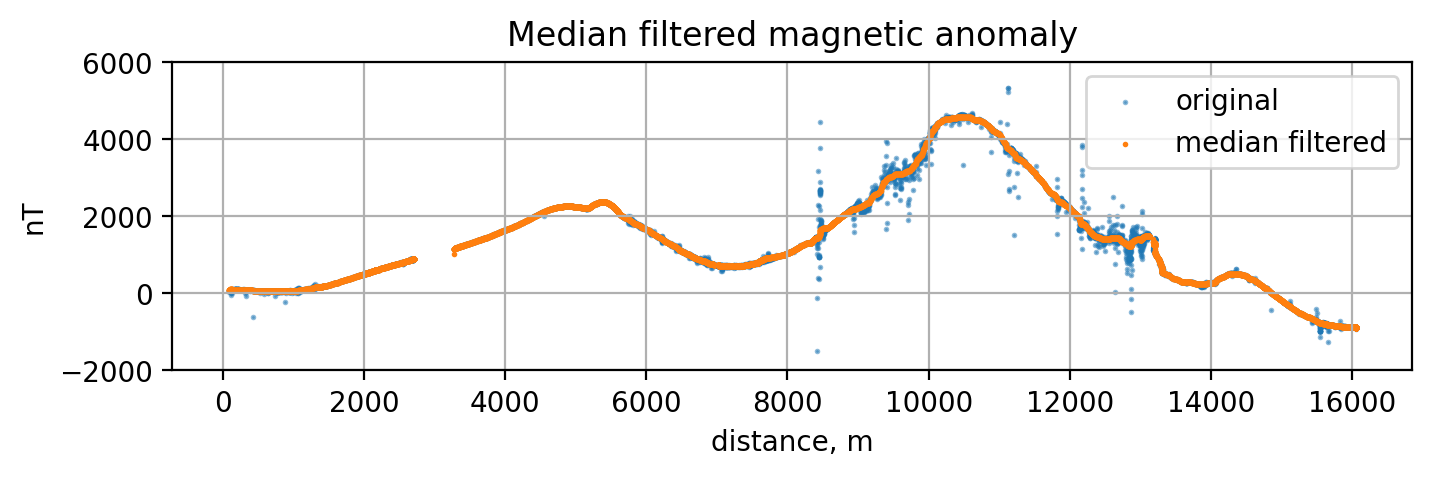

In [18]:
fig,ax = plt.subplots(figsize = (8, 2), dpi = 200, sharex=True)

ax.scatter(rover.distance, rover["nT_corr"], s=1, label=f"original", alpha = 0.5)
ax.scatter(rover.distance, rover["nT_mf"], s=1, label=f"median filtered")
ax.set_ylim(-2000, 6000)
ax.set_ylabel("nT")
ax.set_xlabel("distance, m")
ax.grid()
ax.set_title("Median filtered magnetic anomaly")
ax.legend(loc="upper right")

plt.show()

### **4. Regional trend removal**

Magnetic anomalies are created from various changes in the rocks within the whole crust. In many cases within geological exploration, we are mostly interested in the upper part of the crust - thus we want to remove the effect from the deeper rocks That is done by **regional trend removal**.

There are multiple ways to remove regional trend - but the most straigthforward is to fit an external trend, such as first or second degree polynomial.

In our case we are showcasing how a regional trend would be removed, but we do not employ it this time - mainly due to larger modelling depth within our model later.

In [19]:
# Fit a 1st or 2nd degree polynomial
degree = 2  # 1 for linear, 2 for quadratic

coeffs = np.polyfit(rover['distance'], rover['nT_mf'], degree)
trend = np.polyval(coeffs, rover['distance'])

# Remove the trend
rover['nT_detrend'] = rover['nT_mf'] - trend

View the updated `nT_corr` column.

In [20]:
rover

,latitude,longitude,nT,time,x,y,distance,x_line,y_line,nT_corr,nT_mf,nT_detrend
50,57.021209,24.623766,52056.21,1900-01-01 07:55:20,537871.0,319920.0,81.543058,538220.890377,319811.158337,73.721505,99.708171,718.602920
51,57.021227,24.623804,52035.08,1900-01-01 07:55:22,537873.0,319922.0,84.046860,538221.634091,319813.549134,52.564838,99.799838,717.023301
52,57.021243,24.623844,52031.32,1900-01-01 07:55:24,537875.0,319924.0,86.550661,538222.377805,319815.939932,48.778171,99.991505,715.544192
53,57.021259,24.623875,52034.51,1900-01-01 07:55:26,537877.0,319925.0,88.099596,538222.837891,319817.418958,51.941505,100.283171,714.802516
54,57.021277,24.623907,52042.79,1900-01-01 07:55:28,537879.0,319927.0,90.603398,538223.581605,319819.809756,60.194838,100.753171,713.602565
...,...,...,...,...,...,...,...,...,...,...,...,...
8429,57.155969,24.715035,51085.58,1900-01-01 11:45:36,543255.0,334975.0,16056.295275,542965.933409,335064.920988,-891.601829,-885.425162,-560.688948
8430,57.155974,24.715038,51099.28,1900-01-01 11:44:38,543255.0,334975.0,16056.295275,542965.933409,335064.920988,-877.648495,-885.425162,-560.688948
8431,57.155970,24.715038,51090.39,1900-01-01 11:45:52,543255.0,334975.0,16056.295275,542965.933409,335064.920988,-886.365162,-885.425162,-560.688948
8432,57.155969,24.715039,51090.72,1900-01-01 11:46:02,543255.0,334975.0,16056.295275,542965.933409,335064.920988,-885.768495,-885.425162,-560.688948


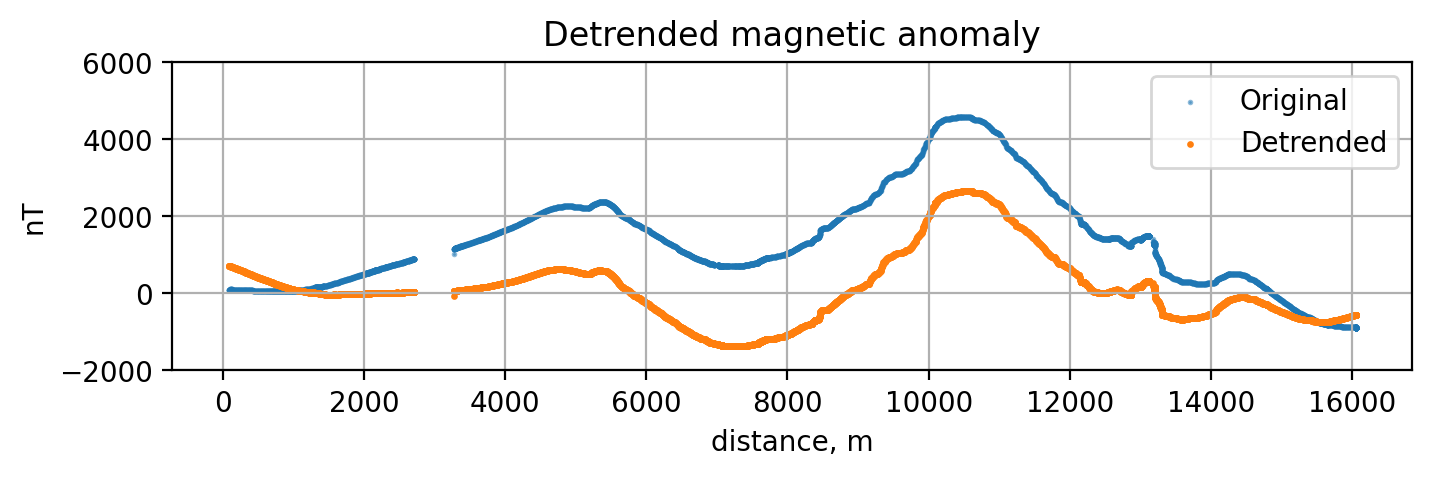

In [21]:
fig,ax = plt.subplots(figsize = (8, 2), dpi = 200, sharex=True)

ax.scatter(rover.distance, rover["nT_mf"], s=1, label=f"Original", alpha = 0.5)
ax.scatter(rover.distance, rover["nT_detrend"], s=2, label=f"Detrended")
# ax.set_ylim(np.min(rover["nT_mf"])*1.1, np.max(rover["nT_mf"])*1.1)
ax.set_ylim(-2000, 6000)

ax.set_ylabel("nT")
ax.set_xlabel("distance, m")
ax.grid()
ax.set_title("Detrended magnetic anomaly")
ax.legend(loc="upper right")

plt.show()

### **5. Downsampling (reducing amount of data)**

We now have over 8384 different magnetic anomaly measurements.
As we will try to do modelling for a large geological body, we do not have to use such large amount of measurements.
We thus will manually downsample - reduce amount of magnetic data - to ease the model calculation.

In [22]:
# Leave only points after specified spacing distance
spacing = 150

first_point = [0]  # always keep first point
for i in range(1, len(rover)):
    if rover['distance'].iloc[i] - rover['distance'].iloc[first_point[-1]] >= spacing:
        first_point.append(i)
rover_full = rover.copy()
rover = rover.iloc[first_point].reset_index(drop=True)

In [23]:
rover

,latitude,longitude,nT,time,x,y,distance,x_line,y_line,nT_corr,nT_mf,nT_detrend
0,57.021209,24.623766,52056.21,1900-01-01 07:55:20,537871.0,319920.0,81.543058,538220.890377,319811.158337,73.721505,99.708171,718.602920
1,57.022273,24.625818,52081.59,1900-01-01 07:57:20,537994.0,320039.0,231.707393,538265.494276,319954.545295,100.481505,97.553171,617.114447
2,57.023350,24.627844,52077.78,1900-01-01 07:59:18,538116.0,320160.0,383.484429,538310.577202,320099.472167,95.318171,81.084838,502.108206
3,57.024426,24.629880,52054.52,1900-01-01 08:01:12,538238.0,320281.0,535.261464,538355.660127,320244.399039,71.078171,67.443171,391.800941
4,57.025405,24.632346,52046.85,1900-01-01 08:03:14,538387.0,320392.0,685.509745,538400.288961,320387.866155,66.201505,62.821505,293.331444
...,...,...,...,...,...,...,...,...,...,...,...,...
98,57.150250,24.711636,51356.04,1900-01-01 11:33:06,543056.0,334336.0,15387.025558,542767.137611,334425.857466,-622.101829,-616.470162,-695.688377
99,57.151362,24.713376,51186.19,1900-01-01 11:35:02,543160.0,334461.0,15537.275451,542811.766924,334569.326121,-790.531829,-756.560162,-748.260391
100,57.153190,24.711117,51156.14,1900-01-01 11:38:54,543021.0,334663.0,15688.870858,542856.795900,334714.079562,-819.781829,-827.496829,-729.035789
101,57.154198,24.713473,51041.72,1900-01-01 11:40:52,543162.0,334777.0,15839.607469,542901.569784,334858.012968,-934.048495,-857.111829,-667.148301


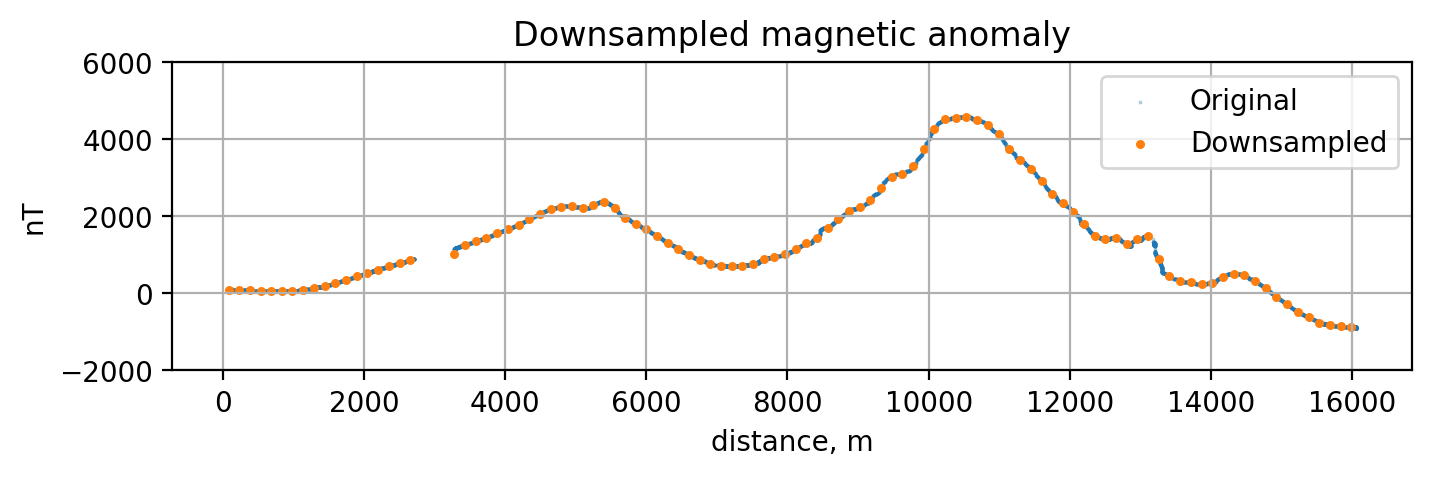

In [24]:
fig,ax = plt.subplots(figsize = (8, 2), dpi = 200, sharex=True)

ax.scatter(rover_full.distance, rover_full["nT_mf"], s=0.1, label=f"Original", alpha = 0.5)
ax.scatter(rover.distance, rover["nT_mf"], s=5, label=f"Downsampled")
ax.set_ylim(-2000, 6000)
ax.set_ylabel("nT")
ax.set_xlabel("distance, m")
ax.grid()
ax.set_title("Downsampled magnetic anomaly")
ax.legend(loc="upper right")

plt.show()

### **Final data**

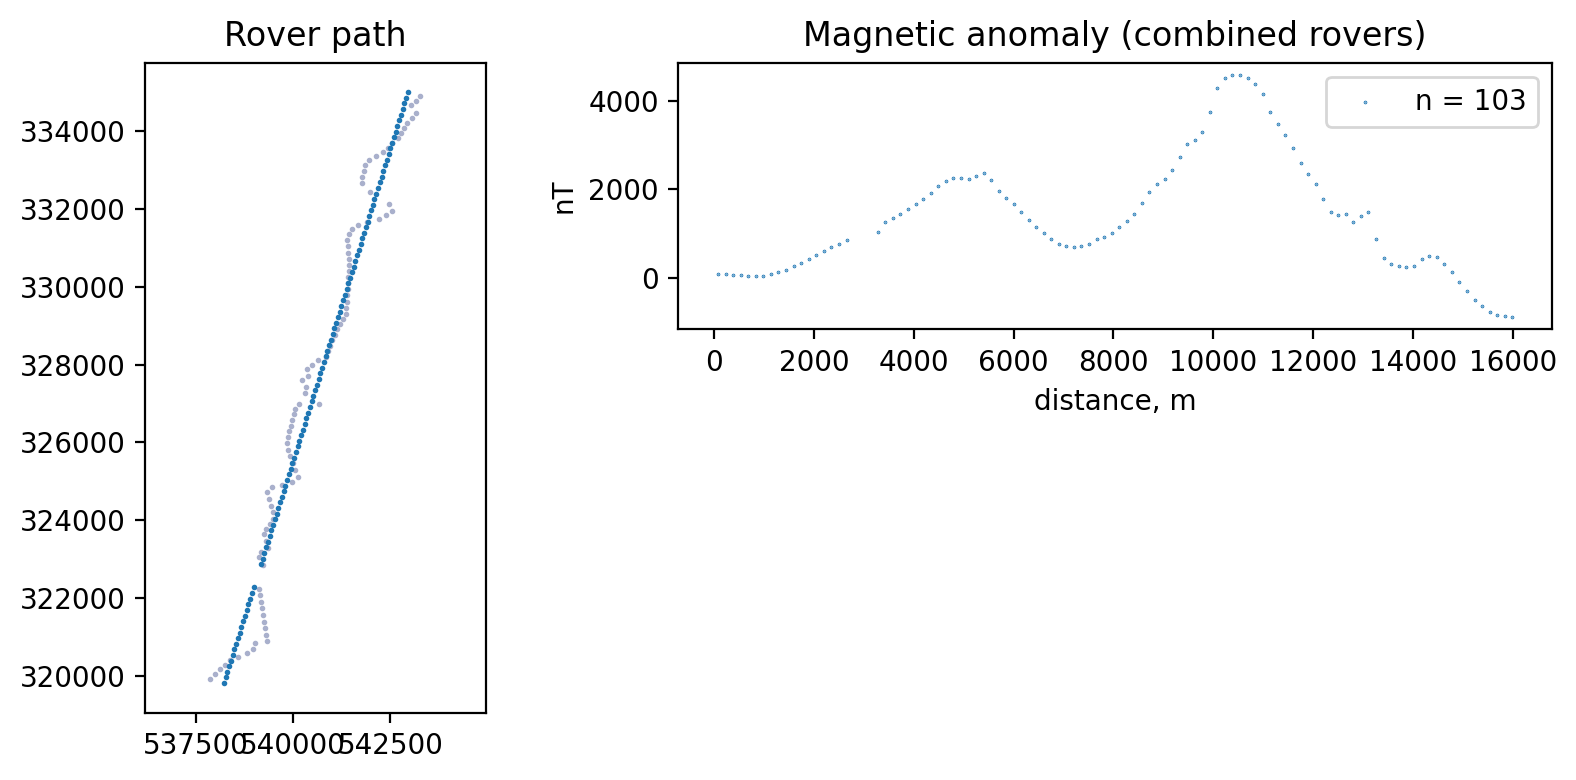

In [25]:
fig = plt.figure(figsize=(8, 4), dpi = 200)

ax1 = plt.subplot2grid((2, 3), (0, 0), rowspan=2)
ax2 = plt.subplot2grid((2, 3), (0, 1), colspan=2)

ax1.scatter(rover["x"], rover["y"], s=1, c="#A9B0CC")
ax1.scatter(rover["x_line"], rover["y_line"], s=1)
ax1.set_title("Rover path")
ax1.axis("equal")

ax2.scatter(rover["distance"], rover["nT_mf"], s=0.1, label=f"n = {len(rover["nT"])}")
ax2.set_ylabel("nT")
ax2.set_xlabel("distance, m")
ax2.set_title("Magnetic anomaly (combined rovers)")
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()

## Modelling the geological body

Finally, we try to forward model the ore body.

We will do this in six steps.
1. Build the coordinate space for the model.
2. Set the observation locations - this we already have done in the first part of the workshop, but we have to reformat them for SimPEG
3. Add the background magnetic field, as we will be working with *induced* magnetic field measurements
4. Load all of the data into the model.
5. Add magnetic dykes into the model
6. Calculate the magnetic anomaly


We will model the ore bodies as different **dykes**.

All of the functionality specific to simulating magnetic data are imported from [simpeg.potential_fields.magnetics](xref:simpeg#simpeg.potential_fields.magnetics).
We also import some useful utility functions from [simpeg.utils](xref:simpeg#simpeg.utils). To simulate magnetic data, we need to define our problem geometry on a numerical grid (or mesh).
To generate the mesh, we used the [discretize](https://discretize.simpeg.xyz/en/main) package.

## 1. Build the coordinate space for the model

In [26]:
[x_topo, y_topo] = np.meshgrid(np.linspace(-2000, 20000, 82), np.linspace(-2000, 20000, 82))
z_topo = np.zeros(x_topo.shape)
x_topo, y_topo, z_topo = mkvc(x_topo), mkvc(y_topo), mkvc(z_topo)
topo_xyz = np.c_[x_topo, y_topo, z_topo]

# Generate mesh with top at z = 0 m
dh = 200.0
hx = [(dh, 5, -1.3), (dh, 20), (dh, 5, 1.3)] # Cells which are defined. 5 padded elongated, 40 normal, 5 padded elongated
hy = [(dh, 5, -1.3), (dh, 80), (dh, 5, 1.3)] # Cells which are defined. 5 padded elongated, 40 normal, 5 padded elongated
# hx = [(dh, 40)] # Cells which are defined. 5 padded elongated, 40 normal, 5 padded elongated
# hy = [(dh, 80)] # Cells which are defined. 5 padded elongated, 40 normal, 5 padded elongated
hz = [(dh, 5, -1.3), (dh, 20)]  # Cells which are defined. 5 padded elongated, 40 normal, 5 padded elongated
mesh = TensorMesh([hx, hy, hz], "CCN")

# Shift vertically to top same as maximum topography
mesh.origin += np.r_[0.0, +8000, z_topo.max()]

# Indices of the active mesh cells from topography (e.g. cells below surface)
active_cells = active_from_xyz(mesh, topo_xyz) # Substracts the active cells from above ground to below ground

# Define mapping from model to active cells. The model consists of a
# susceptibility value for each cell below the Earth's surface.
n_active = int(active_cells.sum())
model_map = maps.IdentityMap(nP=n_active)

## 2. Set the observation locations

We reformat data to SimPEG format

In [27]:
# Define the observation locations as an (N, 3) numpy array or load them.
x = np.linspace(-2000, 2000, 11)
# This will be the model space
y = rover["distance"]
x, y = np.meshgrid(x, y)
x, y = mkvc(x.T), mkvc(y.T)
# Interpolates the survey data
fun_interp = LinearNDInterpolator(np.c_[x_topo, y_topo], z_topo)
z = fun_interp(np.c_[x, y]) + 10  # Flight height 10 m above surface.
receiver_locations = np.c_[x, y, z]

## 3. Set the magnetic background field

In [28]:
# Set the component(s) of the field we want to simulate.
# Here we simulation total magnetic intensity data.
components = ["tmi"]

# Use the observation locations and components to define the receivers. To
# simulate data, the receivers must be defined as a list.
receiver_list = magnetics.receivers.Point(receiver_locations, components=components)
receiver_list = [receiver_list]

# Define the inducing field
inclination = 72  # inclination [deg]
declination = -15  # declination [deg]
amplitude = 51980  # amplitude [nT]

## 4. Load the data into the model

In [29]:
source_field = magnetics.sources.UniformBackgroundField(
    receiver_list=receiver_list,
    amplitude=amplitude,
    inclination=inclination,
    declination=declination,
)

# Define the survey
survey = magnetics.survey.Survey(source_field)

## 5. Add different dykes into the model and forward model the magnetic anomaly

In [30]:
def model(dykes, print_susc=True):
    # Instantiate a vector array. Models in SimPEG are vector arrays.
    model = basement_susceptibility * np.ones(n_active)
    
    # You can use SimPEG utilities to add structures to the model more concisely,
    # or index the mesh cells manually.
    
    # if dykes are empty, then dont plot dyke
    
    for dyke in dykes:
        
        dyke_susceptibility = dyke[0]
        
        xp = np.kron([-2000, 2000], np.ones((4))) # The limits for X dimension
        yp = np.kron(np.ones((2)), [dyke[1], # Bottom left (position)
                                    dyke[1] + dyke[3],  # Bottom right (position + width)
                                    dyke[1] + dyke[3] + dyke[4], # Top right (position + width + offset)
                                    dyke[1] + dyke[4]]) # Top left (position + offset)
        if len(dyke) == 6: # If the optional dyke height is given
            zp = np.kron(np.ones((2)), [-dyke[2], -dyke[2], -dyke[2] + dyke[5], -dyke[2] + dyke[5]]) # Z dimension
        else: # If no height is given
            zp = np.kron(np.ones((2)), [-dyke[2], -dyke[2], -sedimentary_depth, -sedimentary_depth]) # Z dimension
        dyke_points = np.c_[mkvc(xp), mkvc(yp), mkvc(zp)]

        ind_dyke = model_builder.get_indices_polygon(mesh, dyke_points)
        ind_dyke = ind_dyke[active_cells]
        model[ind_dyke] = dyke_susceptibility

    
    # Add sedimentary cover layer
    ind_layer = mesh.gridCC[active_cells, 2] > -sedimentary_depth
    model[ind_layer] = sedimentary_susceptibility
    
    # Mapping to ignore inactive cells when plotting model
    plotting_map = maps.InjectActiveCells(mesh, active_cells, np.nan)
 
    # SIMULATION
    simulation = magnetics.simulation.Simulation3DIntegral(
        survey=survey,
        mesh=mesh,
        model_type="scalar",
        chiMap=model_map,
        active_cells=active_cells,
        store_sensitivities="forward_only",
        engine="choclo",
    )

    # CALCULATION
    dpred = simulation.dpred(model)

    # SIMULATED RESPONSE
    calc_mag = np.column_stack([receiver_list[0].locations, dpred])
    prof_pred = calc_mag[calc_mag[:, 0] == 0] # Get receiver values over the X axis
    
    # Plot them on susceptibility model
    fig = plt.figure(figsize=(12, 12))
    
    # Top plot
    ax0 = fig.add_axes([0.1, 0.57, 0.73, 0.18])
    ax0.scatter(rover["distance"], rover["nT_mf"], s=1, label=f"measured data")
    ax0.scatter(prof_pred[:,1], prof_pred[:,3], label=f"predicted data")
    ax0.set_xlim(0, 16000)
    ax0.set_ylabel("nT")
    ax0.set_xticklabels([])
    ax0.set_title("Predicted vs measured data along survey profile")
    ax0.legend()
    
    # Main model slice
    ax1 = fig.add_axes([0.1, 0.32, 0.73, 0.22])
    
    norm = mpl.colors.LogNorm(vmin=np.min(model), vmax=np.max(model))
    mesh.plot_slice(
        plotting_map * model,
        normal="X",
        ax=ax1,
        ind=int(mesh.shape_cells[0] / 2),
        grid=True,
        # pcolor_opts={"cmap": mpl.cm.plasma, "norm": norm},
        pcolor_opts={"cmap": "inferno_r", "norm": norm},
        range_x=(0, 16000),
        range_y=(-4000, 0),
    )
    # Overlay the susceptibilities
    if print_susc==True:
        # Label basement
        ax1.text(
            x=1000,                        # center of y axis (adjust to your mesh extent)
            y=-basement_depth / 2,      # halfway down the basement
            s=f"{basement_susceptibility} SI",
            ha='center', va='center',
            color='white', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='black', alpha=0.8)
        )
        
        # Label sedimentary layer
        ax1.text(
            x=1000,
            y=-sedimentary_depth / 2,   # halfway through sedimentary layer
            s=f"{sedimentary_susceptibility} SI",
            ha='center', va='center',
            color='white', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='black', alpha=0.8)
        )
    
        # Label each dyke
        for i, dyke in enumerate(dykes):
            dyke_susceptibility = dyke[0]
            dyke_position = dyke[1]       # y position
            dyke_depth = dyke[2]          # depth (positive)
            dyke_width = dyke[3]
            dyke_offset = dyke[4]
        
            # Center of dyke in y and z
            y_center = dyke_position + dyke_offset / 2 + dyke_width / 2
            z_center = -(dyke_depth + sedimentary_depth) / 2
            
            if len(dyke) == 6:
                dyke_height = dyke[5]
                z_center = -dyke_depth + sedimentary_depth / 2
                
        
            ax1.text(
                x=y_center,
                y=z_center,
                s=f"{dyke_susceptibility} SI",
                ha='center', va='center',
                color='white', fontsize=9,
                bbox=dict(boxstyle='round', facecolor='black', alpha=0.8)
            )
        
    ax1.set_title("Model slice along survey profile")
    ax1.set_xlabel("y (m)")
    ax1.set_ylabel("z (m)")


    
    
    # Colorbar
    ax2 = fig.add_axes([0.85, 0.32, 0.03, 0.22])
    cbar = mpl.colorbar.ColorbarBase(
        ax2, norm=norm, orientation="vertical", cmap="inferno_r"
    )
    cbar.set_label("$SI$", rotation=270, labelpad=15, size=16)
    
    # Misfit plot
    ax3 = fig.add_axes([0.1, 0.15, 0.73, 0.1])
    ax3.scatter(rover["distance"], rover["nT_mf"] -  prof_pred[:,3], s=1)
    ax3.set_xlim(0, 16000)
    ax3.axhline(0, lw=1, c="k", alpha=0.5)
    ax3.set_ylabel("nT")
    # ax3.set_xticklabels([])
    ax3.set_title("Misfit")
    
    plt.show()

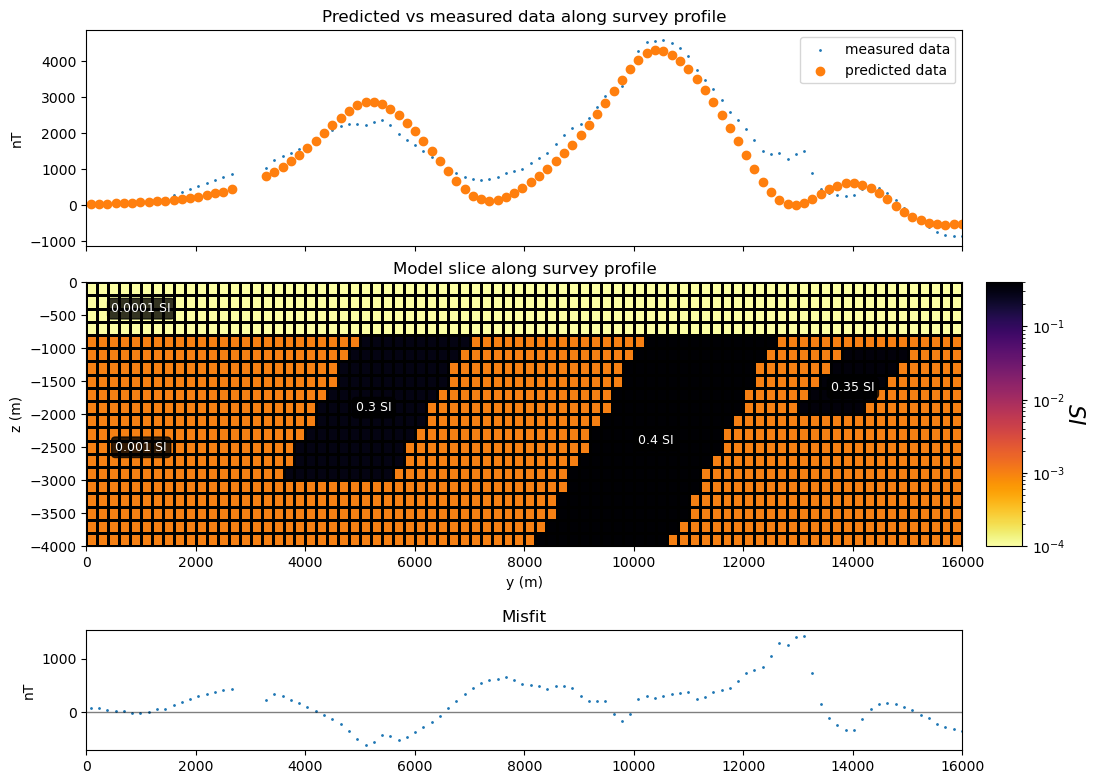

In [31]:
# Define susceptibility values for each unit in SI
basement_susceptibility = 0.001
basement_depth = 5000 # Positive value

sedimentary_susceptibility = 0.0001
sedimentary_depth = 800 # Positive value

dykes = [
# susc., position, depth(positive), width, offset (- or +), height(optional)
    [0.4, 8200, 4000, 2400, 2000],
    [0.3, 3500, 3000, 2000, 1500],
    [0.35, 13000, 2000, 1000, 1000, 1000],
]

model(dykes)

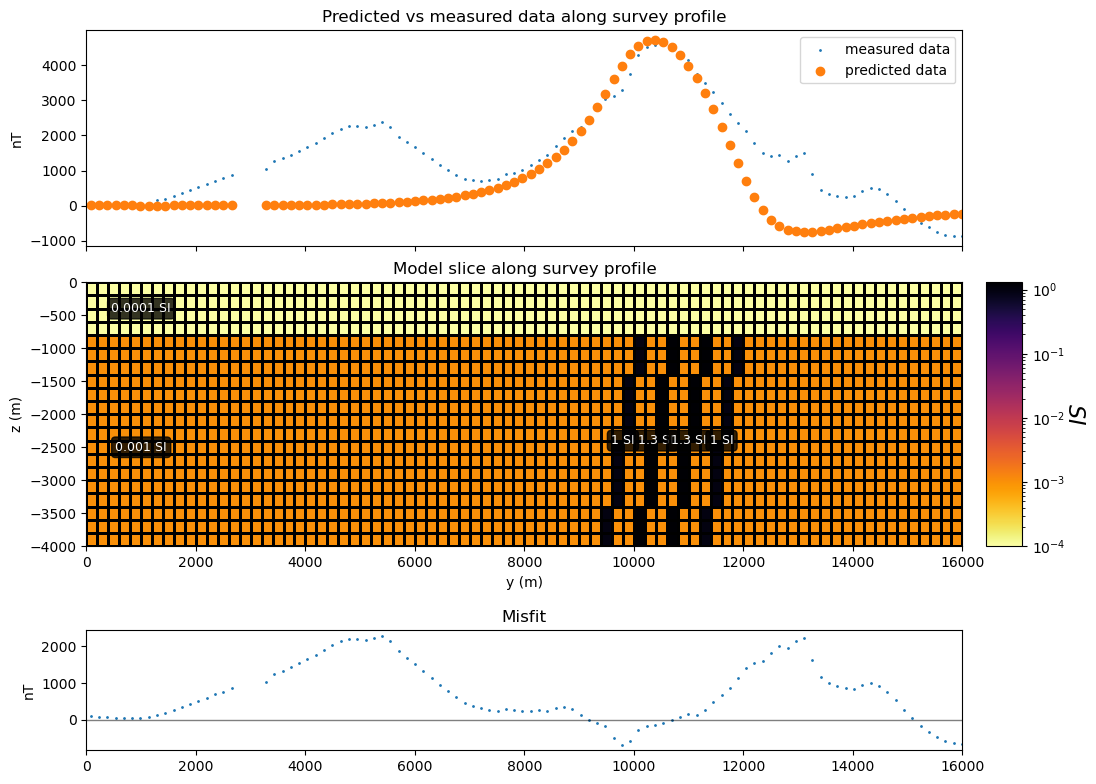

In [32]:
dykes = [
# susc., position, depth(positive), width, offset (- or +), height(optional)
    # [0.1, 11000, 2000, 4000, 600],
    [1, 9400, 4000, 200, 600],
    [1.3, 10000, 4000, 200, 600],
    [1.3, 10600, 4000, 200, 600],
    [1, 11200, 4000, 200, 600],
    # [0.3, 3500, 3000, 2000, 1500],
    # [0.35, 13000, 2000, 1000, 1000, 1000],
]

model(dykes)

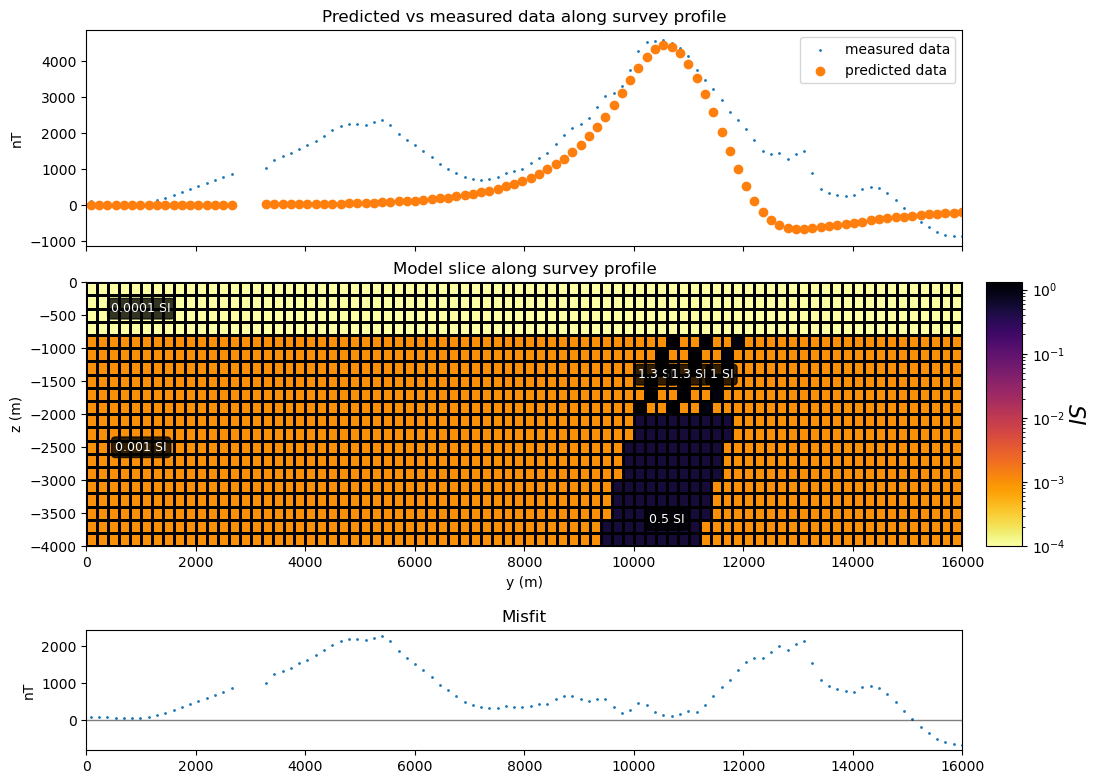

In [33]:
dykes = [
# susc., position, depth(positive), width, offset (- or +), height(optional)
    # [0.1, 11000, 2000, 4000, 600],
    # [1, 9400, 2000, 200, 600],
    [1.3, 10000, 2000, 200, 600],
    [1.3, 10600, 2000, 200, 600],
    [1, 11200, 2000, 200, 600],
    [0.5, 9400, 4000, 1800, 600, 2000],
    # [0.3, 3500, 3000, 2000, 1500],
    # [0.35, 13000, 2000, 1000, 1000, 1000],
]

model(dykes)